In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from os import listdir
from os.path import isfile, join
import matplotlib.font_manager as font_manager
import os

!pip install numpy rclpy rosbag2_py rosidl-runtime-py

import rosbag2_py
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message

# font
font = font_manager.FontProperties()
font.set_family("serif")
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"
font.set_size(60)

import matplotlib.font_manager as fm


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [9]:
def get_header_initialized_dict(file, algo_folder_path):

    dict = {}

    # Print the file path
    file_path = algo_folder_path + "/" + file

    # Load the CSV file
    raw_data = pd.read_csv(file_path)

    # Get headers
    headers = raw_data.columns

    # Initialize the dictionary
    for header in headers:
        dict[header] = []

    return dict


def get_data(folder_path, algorithm):
    """
    Get the data from the CSV files in the folder
    """

    # Get the files in the folder
    algo_folder_path = folder_path + algorithm

    # Get all the CSV files in the folder
    files = [f for f in listdir(algo_folder_path) if isfile(join(algo_folder_path, f))]

    # Initialize the dictionary to store the data
    float_data = get_header_initialized_dict(files[0], algo_folder_path)

    # Convert the data to float
    for file in files:
        # Print the file path
        file_path = algo_folder_path + "/" + file

        # print(f"Loading file: {file_path}")

        # Load the CSV file
        raw_data = pd.read_csv(file_path)

        # Get headers
        headers = raw_data.columns

        raw_data_dict = {}
        for header in headers:
            raw_data_dict[header] = None

        # Store the data in the dictionary
        for header in headers:
            raw_data_dict[header] = raw_data[header].values

        for key in raw_data_dict:
            if key == "Planner":
                continue
            float_data[key].extend(raw_data_dict[key].astype(float).tolist())

            # If there's any nan data - FASTER approach sometimes have nan values in Dynamic A* - remove them
            if np.isnan(float_data[key]).any():
                float_data[key] = [x for x in float_data[key] if not np.isnan(x)]

    return float_data


def get_metrics(float_data):
    """
    Get the average, min, max, and std of the data
    """

    # Initialize the dictionary
    avg_data = {}
    min_data = {}
    max_data = {}
    std_data = {}

    # Get average, min, max, and std of the data
    for key in float_data:
        if key == "Planner":
            continue

        avg_data[key] = np.mean(float_data[key])
        min_data[key] = np.min(float_data[key])
        max_data[key] = np.max(float_data[key])
        std_data[key] = np.std(float_data[key])

    return avg_data, min_data, max_data, std_data


def filter_data(data, for_success_comp=True):

    # Cost (final node's g): if global planning time is 0.0 and the result is 0, then it's after reaching the goal
    if for_success_comp:
        exclude_indices = [
            i
            for i, x in enumerate(data["Total replanning time [ms]"])
            if x == 0.0 or data["Local Traj Time [ms]"][i] == 0
        ]
    else:
        # If we are filtering for failures, we want to exclude indices where the total replanning time is greater than 0.0
        exclude_indices = [
            i
            for i, x in enumerate(data["Total replanning time [ms]"])
            if x == 0.0 or data["Result"][i] == 0
        ]

    # Filter out the failures

    # Get the keys
    keys = list(data.keys())
    for key in keys:
        data[key] = [x for i, x in enumerate(data[key]) if i not in exclude_indices]

    return data

In [10]:
# Get the data

# Define the file path
# folder_path = "/media/kkondo/T7/sando/static/hard_forest/csv/"
folder_path = "/home/kkondo/code/sando_ws/src/sando/benchmark_data/static/hard_20260216_132040/csv"

float_data = get_data(folder_path, "")
float_data_for_success = filter_data(float_data, for_success_comp=True)
float_data = filter_data(
    float_data, for_success_comp=False
)  # we only use computation time when the plan is successful

avg_data_for_success, _, _, _ = get_metrics(float_data_for_success)
avg_data, min_data, max_data, std_data = get_metrics(float_data)

for key in float_data:
    if key == "Planner":
        continue

    if key == "Result":
        print(f"{key}: {avg_data_for_success[key]}")
    else:
        print(key, avg_data[key], min_data[key], max_data[key], std_data[key])
    # print(key, avg_data[key])

Result: 1.0
Cost (final node's g) 50.3708280468445 4.89407 62.4199 10.907986774052787
Total replanning time [ms] 21.482157577098246 6.6998 87.8155 8.29147046181566
Global Planning Time [ms] 0.1670635003253091 0.02 7.264 0.19222179806204878
CVX Decomposition Time [ms] 0.0 0.0 0.0 0.0
Local Traj Time [ms] 6.049425359791803 1.60885 55.7871 3.7816110336711364
Safe Paths Time [ms] 0.0 0.0 0.0 0.0
Safety Check Time [ms] 0.0 0.0 0.0 0.0
Yaw Sequence Time [ms] 0.0 0.0 0.0 0.0
Yaw Fitting Time [ms] 0.0 0.0 0.0 0.0


In [11]:
from rosbag2_py import StorageOptions, ConverterOptions, SequentialReader, StorageFilter


def read_ros2_bag_fast(bag_path, topic_names, message_types, storage_id="sqlite3"):
    """
    One pass over the bag; returns dict: {topic: [msgs]}.
    topic_names: list[str]
    message_types: list[str] matching topic_names 1:1
    """
    type_map = {t: get_message(mt) for t, mt in zip(topic_names, message_types)}

    storage_options = StorageOptions(uri=bag_path, storage_id=storage_id)
    converter_options = ConverterOptions(
        input_serialization_format="cdr", output_serialization_format="cdr"
    )
    reader = SequentialReader()
    reader.open(storage_options, converter_options)
    try:
        reader.set_filter(StorageFilter(topics=topic_names))
    except Exception:
        pass  # older distros

    out = {t: [] for t in topic_names}
    while reader.has_next():
        topic, serialized_msg, _ = reader.read_next()
        # only the filtered topics arrive here
        msg = deserialize_message(serialized_msg, type_map[topic])
        out[topic].append(msg)
    return out


def stream_goal_vectors(bag_path, topic_name, message_type, storage_id="sqlite3"):
    storage_options = rosbag2_py.StorageOptions(uri=bag_path, storage_id=storage_id)
    converter_options = rosbag2_py.ConverterOptions(
        input_serialization_format="cdr", output_serialization_format="cdr"
    )
    reader = rosbag2_py.SequentialReader()
    reader.open(storage_options, converter_options)
    try:
        from rosbag2_py import StorageFilter

        reader.set_filter(StorageFilter(topics=[topic_name]))
    except Exception:
        pass
    msg_type = get_message(message_type)

    t, p, v, a, j = [], [], [], [], []
    while reader.has_next():
        _, ser, _ = reader.read_next()
        m = deserialize_message(ser, msg_type)
        t.append(m.header.stamp.sec + m.header.stamp.nanosec * 1e-9)
        p.append((m.p.x, m.p.y, m.p.z))
        v.append((m.v.x, m.v.y, m.v.z))
        a.append((m.a.x, m.a.y, m.a.z))
        j.append((m.j.x, m.j.y, m.j.z))
    return (np.asarray(t), np.asarray(p), np.asarray(v), np.asarray(a), np.asarray(j))


def process_goal_data(messages, terminal_goal):
    """
    Processes goal data to extract desired values and computes averages.

    Args:
        messages (list): List of ROS 2 messages.

    Returns:
        np.ndarray: Array of extracted values.
    """

    # Extract goal positions
    positions = [[msg.p.x, msg.p.y, msg.p.z] for msg in messages]

    # Extract velocities
    velocities = [
        np.linalg.norm(np.array([msg.v.x, msg.v.y, msg.v.z])) for msg in messages
    ]

    # Extract accelerations
    accelerations = [
        np.linalg.norm(np.array([msg.a.x, msg.a.y, msg.a.z])) for msg in messages
    ]

    # Extract jerk
    jerks = [np.linalg.norm(np.array([msg.j.x, msg.j.y, msg.j.z])) for msg in messages]

    # find start time as when the distance from the start is more than tol
    start_tol = 0.05
    start_time = None
    for i, msg in enumerate(messages):
        dist = np.linalg.norm(
            np.array(
                [
                    msg.p.x - positions[0][0],
                    msg.p.y - positions[0][1],
                    msg.p.z - positions[0][2],
                ]
            )
        )
        if dist > start_tol:
            start_time = msg.header.stamp.sec + msg.header.stamp.nanosec * 1e-9
            break

    goal_tol = 0.5
    # go through the messages and find the time where the goal is reached (the distance is less than 0.1)
    for i, msg in enumerate(messages):
        dist = np.linalg.norm(
            np.array(
                [
                    msg.p.x - terminal_goal[0],
                    msg.p.y - terminal_goal[1],
                    msg.p.z - terminal_goal[2],
                ]
            )
        )
        if dist < goal_tol:
            end_time = msg.header.stamp.sec + msg.header.stamp.nanosec * 1e-9
            end_idx = i + 1  # Include the last message where the goal is reached
            break

    # Get the total time
    total_time = end_time - start_time

    pos_arr = np.array(positions[:end_idx])
    vel_arr = np.array(velocities[:end_idx])
    accel_arr = np.array(accelerations[:end_idx])
    jerk_arr = np.array(jerks[:end_idx])

    return pos_arr, vel_arr, accel_arr, jerk_arr, total_time


def compute_vel_acc_norms(
    messages, start_time=None, terminal_goal=None, reach_thresh=0.5, show=False
):
    """
    DROP-IN replacement (and superset) for your compute_vel_acc_norms usage.

    Returns dict with:
      t:         (N,) time [s], shifted so t[0]=0 (relative time)
      p:         (N,3)
      v,a,j:     (N,3) components
      v_norm,a_norm,j_norm: (N,)
      s:         (N,3) snap estimated from jerk finite-difference
      s_norm:    (N,)
      end_idx:   index (int) where terminal_goal is reached (first time dist <= reach_thresh),
                 or None if never reached
    """

    # --- Extract raw arrays ---
    t_abs = []
    p = []
    v = []
    a = []
    j = []
    for m in messages:
        tt = m.header.stamp.sec + m.header.stamp.nanosec * 1e-9
        t_abs.append(tt)
        p.append([m.p.x, m.p.y, m.p.z])
        v.append([m.v.x, m.v.y, m.v.z])
        a.append([m.a.x, m.a.y, m.a.z])
        j.append([m.j.x, m.j.y, m.j.z])

    t_abs = np.asarray(t_abs, dtype=float)
    p = np.asarray(p, dtype=float)
    v = np.asarray(v, dtype=float)
    a = np.asarray(a, dtype=float)
    j = np.asarray(j, dtype=float)

    if t_abs.size == 0:
        return {
            "t": np.array([]),
            "p": np.zeros((0, 3)),
            "v": np.zeros((0, 3)),
            "a": np.zeros((0, 3)),
            "j": np.zeros((0, 3)),
            "v_norm": np.array([]),
            "a_norm": np.array([]),
            "j_norm": np.array([]),
            "s": np.zeros((0, 3)),
            "s_norm": np.array([]),
            "end_idx": None,
        }

    # --- Filter by start_time if provided ---
    if start_time is not None:
        keep = t_abs >= float(start_time)
        t_abs = t_abs[keep]
        p = p[keep]
        v = v[keep]
        a = a[keep]
        j = j[keep]

    if t_abs.size == 0:
        return {
            "t": np.array([]),
            "p": np.zeros((0, 3)),
            "v": np.zeros((0, 3)),
            "a": np.zeros((0, 3)),
            "j": np.zeros((0, 3)),
            "v_norm": np.array([]),
            "a_norm": np.array([]),
            "j_norm": np.array([]),
            "s": np.zeros((0, 3)),
            "s_norm": np.array([]),
            "end_idx": None,
        }

    # --- Shift time so plots start at 0 ---
    t = t_abs - t_abs[0]

    # --- Norms ---
    v_norm = np.linalg.norm(v, axis=1)
    a_norm = np.linalg.norm(a, axis=1)
    j_norm = np.linalg.norm(j, axis=1)

    # --- Snap estimate: s = d(j)/dt, per axis (finite difference) ---
    # Use forward diff then pad last sample to keep length N
    if t.size >= 2:
        dt = np.diff(t)
        dt = np.clip(dt, 1e-12, None)  # guard
        dj = np.diff(j, axis=0)
        s_fd = dj / dt[:, None]
        # pad last value so shape is (N,3)
        s = np.vstack([s_fd, s_fd[-1]])
    else:
        s = np.zeros_like(j)

    s_norm = np.linalg.norm(s, axis=1)

    # --- end_idx: first time reaching terminal_goal (if given) ---
    end_idx = None
    if terminal_goal is not None and p.shape[0] > 0:
        goal = np.asarray(terminal_goal, dtype=float).reshape(
            3,
        )
        d = np.linalg.norm(p - goal[None, :], axis=1)
        hit = np.where(d <= float(reach_thresh))[0]
        if hit.size > 0:
            end_idx = int(hit[0])

    return {
        "t": t,
        "p": p,
        "v": v,
        "a": a,
        "j": j,
        "v_norm": v_norm,
        "a_norm": a_norm,
        "j_norm": j_norm,
        "s": s,
        "s_norm": s_norm,
        "end_idx": end_idx,
    }


def violation_stats_axis(t, y_comp, limit, mode="samples", end_idx=None, tol_abs=0.001):
    """
    Per-axis violation stats for a (N,3) array y_comp.
    Violation is |y| > limit + tol_abs.

    Returns dict:
      {
        "limit": limit,
        "mode": mode,
        "tol_abs": tol_abs,
        "axis": { "x": {...}, "y": {...}, "z": {...} },
        "any_axis_pct_over": float,
      }
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y_comp, dtype=float)

    if y.ndim != 2 or y.shape[1] != 3:
        raise ValueError(
            f"violation_stats_axis expects y_comp shape (N,3), got {y.shape}"
        )

    if end_idx is None or end_idx > y.shape[0]:
        end_idx = y.shape[0]

    t = t[:end_idx]
    y = y[:end_idx, :]

    out = {
        "limit": limit,
        "mode": mode,
        "tol_abs": float(tol_abs),
        "axis": {},
        "any_axis_pct_over": 0.0,
    }

    if limit is None or y.shape[0] == 0:
        out["axis"] = {
            "x": {
                "pct_over": 0.0,
                "count_over": 0,
                "total_samples": int(y.shape[0]),
                "time_over": 0.0,
                "total_time": 0.0,
            },
            "y": {
                "pct_over": 0.0,
                "count_over": 0,
                "total_samples": int(y.shape[0]),
                "time_over": 0.0,
                "total_time": 0.0,
            },
            "z": {
                "pct_over": 0.0,
                "count_over": 0,
                "total_samples": int(y.shape[0]),
                "time_over": 0.0,
                "total_time": 0.0,
            },
        }
        return out

    lim_eff = float(limit) + float(tol_abs)
    over_xyz = np.abs(y) > lim_eff  # (N,3)

    def _stats_for_axis(ax_idx):
        over = over_xyz[:, ax_idx]
        stats = {
            "count_over": int(np.count_nonzero(over)),
            "total_samples": int(y.shape[0]),
            "pct_over": 0.0,
            "time_over": 0.0,
            "total_time": 0.0,
        }

        if mode == "samples":
            stats["pct_over"] = (
                100.0 * stats["count_over"] / max(stats["total_samples"], 1)
            )
        else:
            if t.size >= 2:
                dt = np.diff(t)
                dt = np.clip(dt, 0.0, None)
                stats["total_time"] = float(np.sum(dt))
                stats["time_over"] = (
                    float(np.sum(dt[over[:-1]])) if dt.size == over.size - 1 else 0.0
                )
                stats["pct_over"] = (
                    100.0 * stats["time_over"] / max(stats["total_time"], 1e-12)
                )
            else:
                stats["pct_over"] = (
                    100.0 * stats["count_over"] / max(stats["total_samples"], 1)
                )
        return stats

    out["axis"]["x"] = _stats_for_axis(0)
    out["axis"]["y"] = _stats_for_axis(1)
    out["axis"]["z"] = _stats_for_axis(2)

    over_any = np.any(over_xyz, axis=1)  # (N,)
    if mode == "samples":
        out["any_axis_pct_over"] = (
            100.0 * float(np.count_nonzero(over_any)) / max(y.shape[0], 1)
        )
    else:
        if t.size >= 2:
            dt = np.diff(t)
            dt = np.clip(dt, 0.0, None)
            time_over = (
                float(np.sum(dt[over_any[:-1]]))
                if dt.size == over_any.size - 1
                else 0.0
            )
            total_time = float(np.sum(dt))
            out["any_axis_pct_over"] = 100.0 * time_over / max(total_time, 1e-12)
        else:
            out["any_axis_pct_over"] = (
                100.0 * float(np.count_nonzero(over_any)) / max(y.shape[0], 1)
            )

    return out


def summarize_constraints_axis(
    plot_data, v_max, a_max, j_max, tol_abs=0.001, mode="samples"
):
    """
    Returns v_stats, a_stats, j_stats computed per axis using plot_data["v"], ["a"], ["j"].
    Violation rule: |component| > limit + tol_abs.
    """
    end_idx = plot_data.get("end_idx", None)
    t = plot_data["t"]

    v_stats = violation_stats_axis(
        t, plot_data["v"], v_max, mode=mode, end_idx=end_idx, tol_abs=tol_abs
    )
    a_stats = violation_stats_axis(
        t, plot_data["a"], a_max, mode=mode, end_idx=end_idx, tol_abs=tol_abs
    )
    j_stats = violation_stats_axis(
        t, plot_data["j"], j_max, mode=mode, end_idx=end_idx, tol_abs=tol_abs
    )
    return v_stats, a_stats, j_stats


def plot_components(
    t,
    v,
    a,
    j,
    end_idx,
    show=True,
    save_path=None,
    width=8.0,
    height=None,
    use_tex=False,
    v_max=2.0,
    a_max=5.0,
    j_max=10.0,
    tol_abs=0.001,
    title_v="Velocity",
    title_a="Acceleration",
    title_j="Jerk",
    show_violations=True,
    violations_until_end=True,
    # ---- new knobs ----
    hspace=0.35,  # space between subplots (exposed)
    legend_font=13,  # smaller legend text
    legend_outside=True,  # keep legend outside the axes on the right
    legend_anchor=(1.02, 0.5),  # (x,y) anchor in axes-fraction coords
    right_margin=0.9,  # figure right boundary for tight_layout rect
):
    """
    Plot v_x,v_y,v_z ; a_x,a_y,a_z ; j_x,j_y,j_z in 3 stacked subplots.

    Modifications:
      - Single legend placed to the right of the stack, entries vertical (x,y,z,limit)
      - Smaller legend text (legend_font)
      - Adjustable vertical spacing via hspace
      - No end-time vertical line (keeps optional post-end shading)
      - Larger axis labels/titles/ticks
      - y-labels use vector notation with units (\vect{} if use_tex else bold)
      - Titles are just: Velocity / Acceleration / Jerk
    """
    import numpy as np
    import matplotlib.pyplot as plt

    t = np.asarray(t, dtype=float)
    v = np.asarray(v, dtype=float)
    a = np.asarray(a, dtype=float)
    j = np.asarray(j, dtype=float)

    phi = (1 + 5**0.5) / 2
    if height is None:
        height = (width / phi) * 0.95

    # -------------------- Global style --------------------
    if use_tex:
        plt.rcParams.update(
            {
                "text.usetex": True,
                # define \vect so "$\vect{v}$" works
                "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}\newcommand{\vect}[1]{\bm{#1}}",
            }
        )
    else:
        plt.rcParams.update({"text.usetex": False})
        candidates = [
            "Times New Roman",
            "Nimbus Roman",
            "TeX Gyre Termes",
            "Times",
            "CMU Serif",
            "DejaVu Serif",
        ]
        avail = {f.name for f in fm.fontManager.ttflist}
        chosen = next((c for c in candidates if c in avail), "DejaVu Serif")
        plt.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = [chosen]

    # Typography (still "bigger" for axes, but legend is independently smaller)
    base_font = 18
    title_font = 20
    label_font = 16
    tick_font = 16
    plt.rcParams["font.size"] = base_font

    fig, (ax_v, ax_a, ax_j) = plt.subplots(
        3, 1, sharex=True, figsize=(width, height), gridspec_kw=dict(hspace=hspace)
    )

    def vect_label(sym: str) -> str:
        return rf"$\vect{{{sym}}}$" if use_tex else rf"$\mathbf{{{sym}}}$"

    def mark_end_region(ax):
        """No vertical end-time line; keeps only a light shaded region after end_idx."""
        if end_idx is None:
            return
        if isinstance(end_idx, (int, np.integer)) and 0 <= int(end_idx) < len(t):
            t_end = t[int(end_idx)]
            ax.axvspan(t_end, t[-1], ymin=0.0, ymax=1.0, alpha=0.10, color="gray")

    def plot_xyz(ax, y, lim, ylabel, title):
        # components
        lx = ax.plot(t, y[:, 0], lw=2.2, label="x")[0]
        ly = ax.plot(t, y[:, 1], lw=2.2, label="y")[0]
        lz = ax.plot(t, y[:, 2], lw=2.2, label="z")[0]
        lines = [lx, ly, lz]

        lim_handle = None
        if lim is not None:
            lim = float(lim)
            lim_eff = lim + float(tol_abs)

            # limit lines; label only once for legend ("limit")
            lim_handle = ax.axhline(+lim, ls=":", lw=1.8, color="k", label="limit")
            ax.axhline(-lim, ls=":", lw=1.8, color="k", label="_nolegend_")

            if show_violations:
                if violations_until_end and end_idx is not None:
                    end_eff = int(end_idx) + 1
                    end_eff = max(0, min(end_eff, y.shape[0]))
                else:
                    end_eff = y.shape[0]

                over = np.abs(y[:end_eff, :]) > lim_eff
                for k in range(3):
                    idx = np.where(over[:, k])[0]
                    if idx.size > 0:
                        ax.plot(
                            t[idx],
                            y[idx, k],
                            linestyle="None",
                            marker="o",
                            markersize=4.5,
                            alpha=0.7,
                            color=lines[k].get_color(),
                        )

            # y-limits
            yabs = np.max(np.abs(y)) if y.size else 1.0
            ymax = max(1.15 * yabs, 1.15 * lim)
            ax.set_ylim(-ymax, ymax)

        ax.set_ylabel(ylabel, fontsize=label_font)
        ax.set_title(title, fontsize=title_font)
        ax.grid(True, ls="--", alpha=0.35)
        ax.tick_params(axis="both", labelsize=tick_font)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # mark_end_region(ax)
        return lines, lim_handle

    # Plot
    v_lines, _ = plot_xyz(ax_v, v, v_max, rf"{vect_label('v')} [m/s]", title_v)
    a_lines, _ = plot_xyz(ax_a, a, a_max, rf"{vect_label('a')} [m/s$^2$]", title_a)
    j_lines, j_lim = plot_xyz(ax_j, j, j_max, rf"{vect_label('j')} [m/s$^3$]", title_j)

    ax_j.set_xlabel("Time [s]", fontsize=label_font)
    ax_j.tick_params(axis="x", labelsize=tick_font)

    # -------------------- Right-side vertical legend (middle-right) --------------------
    handles = [j_lines[0], j_lines[1], j_lines[2]]
    labels = ["x", "y", "z"]
    if j_lim is not None:
        handles.append(j_lim)
        labels.append("limit")

    # Make room on the right for the legend
    plt.tight_layout(rect=[0.0, 0.0, right_margin, 1.0])

    if legend_outside:
        # Figure-level legend centered vertically (middle-right)
        fig.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(right_margin + 0.02, 0.5),  # (x, y) in figure coords
            frameon=False,
            fontsize=legend_font,
            ncol=1,  # vertical stack
            borderaxespad=0.0,
            handlelength=2.6,
            labelspacing=0.6,
        )
    else:
        # Fallback: inside ax_j
        ax_j.legend(
            handles, labels, frameon=False, fontsize=legend_font, ncol=1, loc="best"
        )

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", dpi=300)

    if show:
        plt.show()

    return {"fig": fig, "ax_v": ax_v, "ax_a": ax_a, "ax_j": ax_j}


def violation_stats(t, y, limit, mode="time", end_idx=None, tol_abs=0.001):
    """
    Scalar violation stats.
    Violation is y > limit + tol_abs.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if end_idx is None or end_idx > len(y):
        end_idx = len(y)
    t = t[:end_idx]
    y = y[:end_idx]

    out = {
        "limit": limit,
        "mode": mode,
        "tol_abs": float(tol_abs),
        "count_over": 0,
        "total_samples": int(y.size),
        "pct_over": 0.0,
        "time_over": 0.0,
        "total_time": 0.0,
    }

    if limit is None or y.size == 0:
        return out

    over = y > (float(limit) + float(tol_abs))

    if mode == "samples":
        out["count_over"] = int(np.count_nonzero(over))
        out["pct_over"] = 100.0 * out["count_over"] / max(out["total_samples"], 1)
    else:
        if t.size >= 2:
            dt = np.diff(t)
            dt = np.clip(dt, 0.0, None)
            out["total_time"] = float(np.sum(dt))
            out["time_over"] = (
                float(np.sum(dt[over[:-1]])) if dt.size == over.size - 1 else 0.0
            )
            out["pct_over"] = 100.0 * out["time_over"] / max(out["total_time"], 1e-12)
        else:
            out["count_over"] = int(np.count_nonzero(over))
            out["pct_over"] = 100.0 * out["count_over"] / max(out["total_samples"], 1)

    return out

In [12]:
base_path = "/home/kkondo/code/sando_ws/src/sando/benchmark_data/static/hard_20260216_132040/bags"
topic_name = "/NX01/goal"
message_type = "dynus_interfaces/msg/Goal"  # Update with your message type
term_goal_topic_name = "/NX01/term_goal"
term_goal_message_type = (
    "geometry_msgs/msg/PoseStamped"  # Update with your message type
)
number_of_bags = 10

# Boolean
get_data_for_plot = True  # set to False if you want to compute statistics only


### NEW: helper to integrate with trapezoid rule up to end_idx (inclusive)
def trapz_until(t, y, end_idx=None):
    import numpy as np

    if len(t) == 0 or len(y) == 0:
        return 0.0
    if end_idx is None:
        return float(np.trapz(y, t))
    idx = int(end_idx)
    idx = max(0, min(idx, len(t) - 1))
    return float(np.trapz(y[: idx + 1], t[: idx + 1]))


# Initialize arrays to store data
pos_array = np.array([])
vel_array = np.array([])
accel_array = np.array([])
jerk_array = np.array([])
J_smooth_array = np.array([])  # per-run RMS jerk
S_eff_array = np.array([])  # per-run RMS snap (time-normalized)
travel_time_array = np.array([])
path_length_array = np.array([])
plot_data_list = []

### NEW: per-N smoothness (∫||j||dt) storage
smoothness_array = np.array([])

for i in range(number_of_bags):
    bag_path = f"{base_path}/trial_{i}"
    print(f"processing bag: {bag_path}")

    # Get simulation start time as the terminal goal sent time
    data = read_ros2_bag_fast(
        bag_path,
        [term_goal_topic_name, topic_name],
        [term_goal_message_type, message_type],
        storage_id="sqlite3",  # or "mcap" if you convert
    )
    terminal_goal_messages = data[term_goal_topic_name]
    messages = data[topic_name]

    plot_start_time = (
        terminal_goal_messages[0].header.stamp.sec
        + terminal_goal_messages[0].header.stamp.nanosec * 1e-9
    )

    if not messages:
        print(f"No messages found or topic does not exist in {bag_path}.")
    else:
        # Process data
        pos, vel, accel, jerk, travel_time = process_goal_data(
            messages, terminal_goal=[105, 0, 3]
        )

        # Compute norms/time series for plotting & stats
        plot_data = compute_vel_acc_norms(
            messages,
            start_time=plot_start_time,
            terminal_goal=[105, 0, 3],
            reach_thresh=0.5,
            show=False,
        )
        plot_data_list.append(plot_data)

        t = plot_data["t"]
        j_norm = plot_data["j_norm"]  # ||jerk||  [m/s^3]
        s_norm = plot_data["s_norm"]  # ||snap||  [m/s^4]
        end_idx = plot_data.get("end_idx", None)

        # Robust end index for integration and duration
        if end_idx is None or end_idx >= len(t):
            end_eff = len(t) - 1
        else:
            end_eff = int(end_idx)

        # --- Jerk integral: ∫ ||j|| dt ---
        J_int = trapz_until(t, j_norm, end_idx=end_eff)  # [m/s^2]
        jerk_array = np.append(jerk_array, J_int)
        print(f"J_int (∫||j||dt): {J_int:.6f}  [m/s^2]")

        # --- J_smooth: RMS jerk = sqrt( (1/T) ∫ ||j||^2 dt ) ---
        J2 = trapz_until(t, j_norm**2, end_idx=end_eff)  # [m^2/s^5]
        T_run = max(t[end_eff] - t[0], 1e-12)  # [s]
        J_smooth = np.sqrt(J2 / T_run)  # [m/s^3]
        J_smooth_array = np.append(J_smooth_array, J_smooth)
        print(f"J_smooth (RMS jerk): {J_smooth:.6f}  [m/s^3]")

        # --- S_eff: RMS snap = sqrt( (1/T) ∫ ||s||^2 dt ) ---
        S2 = trapz_until(t, s_norm**2, end_idx=end_eff)  # [m^2/s^7]
        S_eff = np.sqrt(S2 / T_run)  # [m/s^4]
        S_eff_array = np.append(S_eff_array, S_eff)
        print(f"S_eff (RMS snap): {S_eff:.6f}  [m/s^4]")

        # ---------- violation summary (unchanged) ----------
        mode = "samples"
        v_max, a_max, j_max = 2.0, 5.0, 10.0
        v_stats, a_stats, j_stats = summarize_constraints_axis(
            plot_data, v_max=2.0, a_max=5.0, j_max=10.0, tol_abs=0.001, mode="samples"
        )

        print(
            f"[violations | {mode}] any-axis%  "
            f"vel: {v_stats['any_axis_pct_over']:.2f}%  "
            f"acc: {a_stats['any_axis_pct_over']:.2f}%  "
            f"jerk: {j_stats['any_axis_pct_over']:.2f}%"
        )

        print(
            f"  vel axis%: x={v_stats['axis']['x']['pct_over']:.2f} "
            f"y={v_stats['axis']['y']['pct_over']:.2f} "
            f"z={v_stats['axis']['z']['pct_over']:.2f}"
        )

        print(
            f"  acc axis%: x={a_stats['axis']['x']['pct_over']:.2f} "
            f"y={a_stats['axis']['y']['pct_over']:.2f} "
            f"z={a_stats['axis']['z']['pct_over']:.2f}"
        )

        print(
            f" jerk axis%: x={j_stats['axis']['x']['pct_over']:.2f} "
            f"y={j_stats['axis']['y']['pct_over']:.2f} "
            f"z={j_stats['axis']['z']['pct_over']:.2f}"
        )

        # Plot the norms
        if get_data_for_plot:
            plot_components(
                plot_data["t"],
                plot_data["v"],
                plot_data["a"],
                plot_data["j"],
                plot_data.get("end_idx", None),
                tol_abs=0.001,
                show=False,
                # save_path=f"{base_paper_path}/num_{i}/components.pdf",
                save_path=None,
                width=8.0,
                use_tex=True,
                v_max=2.0,
                a_max=5.0,
                j_max=10.0,
                title_v="Velocity",
                title_a="Acceleration",
                title_j="Jerk",
            )

        # Append to the arrays
        pos_array = np.append(pos_array, pos)
        vel_array = np.append(vel_array, vel)
        accel_array = np.append(accel_array, accel)
        travel_time_array = np.append(travel_time_array, travel_time)

        # compute path length
        path_length = 0
        for k in range(len(pos) - 1):  # <- rename loop var to avoid shadowing i
            path_length += np.linalg.norm(pos[k + 1] - pos[k])
        path_length_array = np.append(path_length_array, path_length)

        print(f"average velocity: {np.mean(vel):.6f} m/s")
        print(f"travel time: {travel_time:.6f} seconds")
        print(f"path length: {path_length:.6f} meters")

print(
    "ave travel time: ",
    float(np.mean(travel_time_array)) if travel_time_array.size else None,
)
print(
    "ave path length: ",
    float(np.mean(path_length_array)) if path_length_array.size else None,
)
print("ave J_int: ", float(np.mean(jerk_array)) if jerk_array.size else None)
print("ave J_smooth: ", float(np.mean(J_smooth_array)) if J_smooth_array.size else None)
print("ave S_eff: ", float(np.mean(S_eff_array)) if S_eff_array.size else None)

processing bag: /home/kkondo/code/sando_ws/src/sando/benchmark_data/static/hard_20260216_132040/bags/trial_0


[INFO] [1771357487.301857757] [rosbag2_storage]: Opened database '/home/kkondo/code/sando_ws/src/sando/benchmark_data/static/hard_20260216_132040/bags/trial_0/trial_0_0.db3' for READ_ONLY.


UnsupportedTypeSupport: Could not import 'rosidl_typesupport_c' for package 'dynus_interfaces'

/tmp/ipykernel_3831774/1483017137.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.0, right_margin, 1.0])


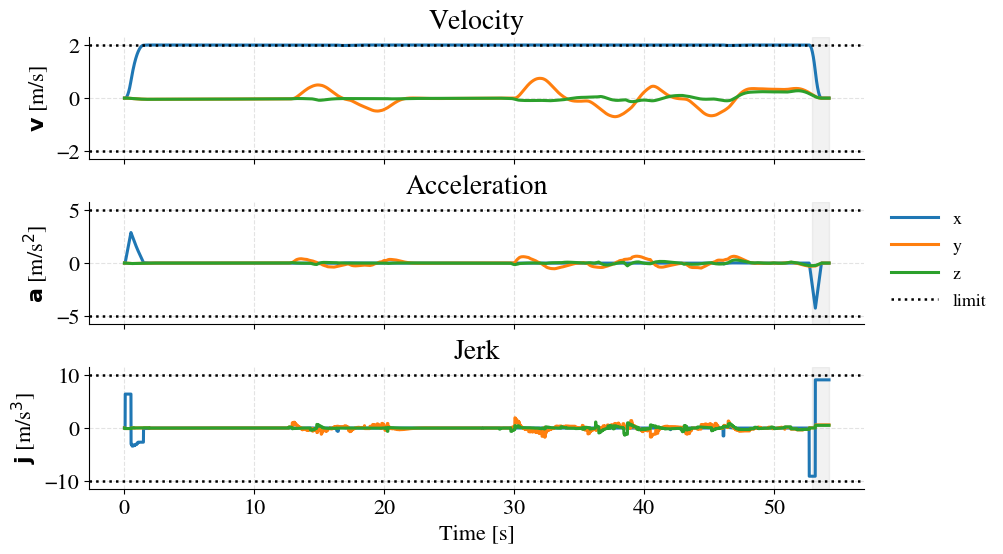

{'fig': <Figure size 1000x587.132 with 3 Axes>,
 'ax_v': <Axes: title={'center': 'Velocity'}, ylabel='$\\mathbf{v}$ [m/s]'>,
 'ax_a': <Axes: title={'center': 'Acceleration'}, ylabel='$\\mathbf{a}$ [m/s$^2$]'>,
 'ax_j': <Axes: title={'center': 'Jerk'}, xlabel='Time [s]', ylabel='$\\mathbf{j}$ [m/s$^3$]'>}

In [ ]:
# Plot the velocity / acceleration / jerk components (per-axis)

# file_path = "/home/kkondo/paper_writing/sando_paper/sando_paper/figures/medium_forest"
file_path = "/home/kkondo/paper_writing/sando_paper/sando_paper/figures/hard_forest"

run_number = 3
pd = plot_data_list[run_number]

time = pd["t"]
v_xyz = pd["v"]  # (N,3)
a_xyz = pd["a"]  # (N,3)
j_xyz = pd["j"]  # (N,3)

title_v = "Velocity"
title_a = "Acceleration"
title_j = "Jerk"

plot_components(
    time,
    v_xyz,
    a_xyz,
    j_xyz,
    pd.get("end_idx", None),
    tol_abs=0.001,
    show=True,
    save_path=f"{file_path}/num_{run_number}_sando_components.pdf",
    width=10.0,
    use_tex=False,
    v_max=2.0,
    a_max=5.0,
    j_max=10.0,
    title_v=title_v,
    title_a=title_a,
    title_j=title_j,
)